<a href="https://colab.research.google.com/github/SANTONLA/RECONOCEDOR-DIGITOS/blob/main/07_Proyecto_ReconocedorDeDigitos_santon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch==2.3.1 \
             torchvision==0.18.1 \
             fastai \
             fastdownload \
             fastprogress \
             --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!python --version


Python 3.12.12


In [3]:
import sys
import fastai
import torch
import torchvision
import fastprogress
import fastdownload

print("Python version:", sys.version)
print("fastai version:", fastai.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)
print("fastprogress version:", fastprogress.__version__)
print("fastdownload version:", fastdownload.__version__)
print("CUDA available:", torch.cuda.is_available())



Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
fastai version: 2.8.6
torch version: 2.3.1+cu121
torchvision version: 0.18.1+cu121
fastprogress version: 1.1.3
fastdownload version: 0.0.7
CUDA available: False


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive




#### Módulo 1: Python para la ciencia de datos

### 📚 Proyecto: reconocedor de dígitos

🔎 Este proyecto está basado en la base de datos MNIST.

### 📜 Historia y origen de MNIST

📅 ¿Cuándo y por qué empezó MNIST?
MNIST fue creado en 1998 por Yann LeCun, Corinna Cortes y Christopher J.C. Burges.

⚙️ Surge como una versión mejorada y estandarizada de un conjunto anterior llamado NIST (National Institute of Standards and Technology).

🎯 El objetivo era proporcionar un benchmark sencillo, limpio y accesible para evaluar algoritmos de reconocimiento de patrones y aprendizaje automático.

❌ Antes de MNIST, no había un conjunto de datos simple y universal para comparar modelos en la tarea de reconocimiento de dígitos manuscritos.

🚀 Con MNIST, se popularizó la evaluación comparativa en problemas reales de clasificación.

### 🤔 ¿Por qué MNIST fue un avance importante?

✅ Uniformidad: Datos bien organizados, etiquetados y con división clara entre entrenamiento y test.

📊 Tamaño manejable: 70,000 imágenes, lo suficientemente grande para entrenar modelos básicos, pero pequeño para ser procesado en computadoras estándar.

🖼️ Sencillez: Imágenes en escala de grises y tamaño pequeño (28x28).

🌐 Accesibilidad: Disponible gratuitamente y fácil de usar.

###Importamos librerias

In [5]:
#Importamos las librerías necesarias

import numpy as np             # NumPy: proporciona soporte para arreglos multidimensionales y funciones matemáticas de alto nivel.
from skimage import io         # scikit-image (io): permite leer y guardar imágenes en varios formatos.
import os                      # OS: proporciona funciones para interactuar con el sistema operativo (como navegar directorios, gestionar archivos, etc.).
import time                    # Time: permite trabajar con funciones relacionadas con el tiempo, como medir duración o hacer pausas (sleep).
import matplotlib.pyplot as plt  # Matplotlib: biblioteca para crear gráficos y visualizaciones en 2D.
import seaborn as sns          # Seaborn: basada en matplotlib, permite crear gráficos estadísticos más atractivos y con menos código.
import tifffile as tf          # Tifffile: especializada en la lectura/escritura de archivos TIFF, especialmente útiles en microscopía.
import glob as glob            # Glob: busca archivos que coincidan con un patrón (por ejemplo, todos los `.tif` en una carpeta).
import scipy as sp             # SciPy: ofrece algoritmos y herramientas matemáticas avanzadas (optimizaciones, estadísticas, procesamiento de señales, etc.).


En este proyecto vas a crear un reconocedor de dígitos. Para ello vas a basarte en un conjunto muy grande de imágenes de dígitos manuscritos. Todas estas imágenes tienen un tamaño de 28 x 28 píxeles. A continnuación te muestro un ejemplo con 10 imágenes de cada dígito.

Para leer cada una de estas imágenes tienes a tu disposición la función leerImagen, que recibe el nombre del archivo que contiene la imagen que quieres leer y devuelve una matriz de numpy. Como las imágenes de dígitos son de 28x 28 píxeles, la matriz que obtendrás será de 28x28 elementos. Cada uno de estos elementos es un número real entre 0 y 1, que marca todas las tonalidades de gris entre el negro (valor 0.0) y el blanco (valor 1.0).

Para mostrar una imagen almacenada en una matriz de numpy, puedes utilizar la función mostrarImagen, que recibe la matriz de numpy como único argumento.

### Creamos las funciones necesarias para leer y mostrar imágenes

In [6]:
#Funciones útiles para leer y mostrar imágenes
def leerImagen(fichero):
    leida = io.imread(fichero, as_gray=True)
    return leida
def mostrarImagen(fichero):
    return io.imshow(fichero)

A la hora de crear el reconocedor tienes disponibles muchas imágenes de dígitos en dos carpetas distintas: *imagenes_train* e *imagenes_test*. En cada una de las carpetas, el nombre de los archivos sigue una estructura similar:
* cuatro dígitos que indican el número de archivo dentro de la carpeta
* _ como separación
* un dígito que toma el valor del dígito representado en la imagen
* .png es la extensión de la imagen
Las imágenes almacenadas en la carpeta *imagenes_train* son las que vamos a utilizar como conjunto de entrenamiento. En este conjunto, de cada dato conocemos los valores de sus atributos (cada píxel de la imagen es un atributo) y la clase a la que pertenece el dato. En nuestro problema tenemos 10 clases, que corresponden a los 10 dígitos.

Vas a comenzar preparando los datos de entrenamiento. Tu objetivo es conseguir una matriz que tenga tantas filas como imágenes haya en la carpeta y tantas columnas como píxeles haya en una imagen. Para ello, debes leer todas las imágenes contenidas en la carpeta *imagenes_train*. Cada imagen es un dato (ejemplo) y debes transformarlo para poder almacenarlo en una fila de la matriz. Además, de cada imagen queremos saber la clase a la que pertenece, por lo que debes extraer del nombre del fichero el dígito que representa y almacenarlo en un vector de numpy. Este vector debe contener números enteros.

Por tanto, nuestro conjunto de entrenamiento va a estar formado por una matriz de numpy que guarda todos los atributos de las imágenes (le llamamos *trainData*) y un vector de numpy que almacena las clases de cada imagen (le llamamos *trainClass*).

### Importamos desde Kaggle

In [7]:
import kagglehub

# Descargar el dataset desde Kaggle
path = kagglehub.dataset_download("mannu1170/minst-dataset")  # ✅ Solo el ID, no el URL completo

print("Ruta local del dataset:", path)


100%|██████████| 11.0M/11.0M [00:02<00:00, 5.29MB/s]

Extracting files...


Ruta local del dataset: /root/.cache/kagglehub/datasets/mannu1170/minst-dataset/versions/1



### Movemos la carpeta a content para que vaya mas rapido

In [8]:
import shutil
import os

# We ignore hidden files (starting with '.') to avoid permission errors with system/NFS files
def ignore_hidden(path, names):
    return [name for name in names if name.startswith('.')]

try:
    shutil.copytree(path, "/content/minst-dataset", dirs_exist_ok=True, ignore=ignore_hidden)
    print("Dataset copied successfully to /content/minst-dataset")
except Exception as e:
    print(f"Error copying dataset: {e}")

Dataset copied successfully to /content/minst-dataset


###Listamos archivos de la carpeta

In [9]:
import os

dataset_path = "/content/minst-dataset"

# Asegurarse de que la ruta existe antes de listar archivos
if os.path.exists(dataset_path):
    files = os.listdir(dataset_path)
    print("Archivos en la carpeta del dataset:")
    for file in files:
        print(file)
else:
    print("La carpeta no existe. Verifica la ruta:", dataset_path)
files = os.listdir(dataset_path)



Archivos en la carpeta del dataset:
t10k-images.idx3-ubyte
train-images.idx3-ubyte
t10k-labels.idx1-ubyte
train-labels.idx1-ubyte


In [10]:
import os

dataset_path = "/content/minst-dataset"  # Ojo al typo: 'mnist' no 'minst'

if os.path.exists(dataset_path):
    files = os.listdir(dataset_path)
    print("Archivos en la carpeta del dataset:")
    for file in files:
        print(file)
else:
    print("La carpeta no existe. Verifica la ruta:", dataset_path)


Archivos en la carpeta del dataset:
t10k-images.idx3-ubyte
train-images.idx3-ubyte
t10k-labels.idx1-ubyte
train-labels.idx1-ubyte


### Leer los archivos IDX en Python

In [11]:
pip install idx2numpy


  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=7d70e897bb03293807715b170aec7977fb9b75ba911480d8ac36c47ff1be4835
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [12]:
import idx2numpy
import os


# Rutas
train_images_path = os.path.join(dataset_path, "train-images.idx3-ubyte")
train_labels_path = os.path.join(dataset_path, "train-labels.idx1-ubyte")

# Cargar datos
train_images = idx2numpy.convert_from_file(train_images_path)
train_labels = idx2numpy.convert_from_file(train_labels_path)

print("Shape de imágenes:", train_images.shape)  # (60000, 28, 28)
print("Shape de etiquetas:", train_labels.shape)  # (60000,)


Shape de imágenes: (60000, 28, 28)
Shape de etiquetas: (60000,)


In [13]:
os.listdir()

['.config', 'drive', 'minst-dataset', 'sample_data']

{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


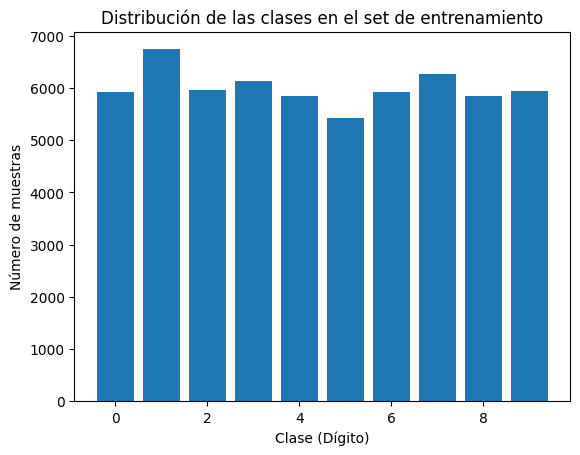

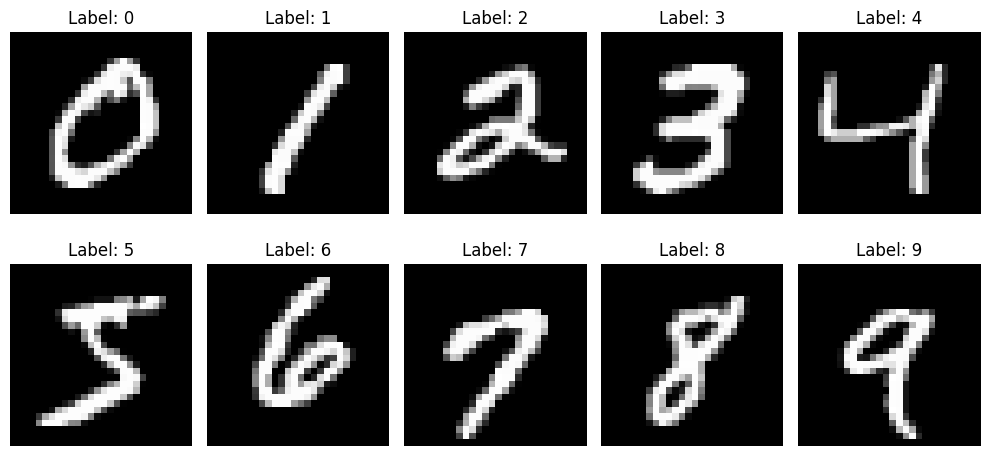

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Contar la cantidad de imágenes por cada clase
unique, counts = np.unique(train_labels, return_counts=True)
class_counts = dict(zip(unique, counts))

print(class_counts)

# Visualizar la distribución de clases
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Clase (Dígito)')
plt.ylabel('Número de muestras')
plt.title('Distribución de las clases en el set de entrenamiento')
plt.show()

# Mostrar algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    # Tomar la primera imagen que corresponda a cada clase
    idx = np.where(train_labels == i)[0][0]
    ax.imshow(train_images[idx], cmap='gray')
    ax.set_title(f'Label: {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()


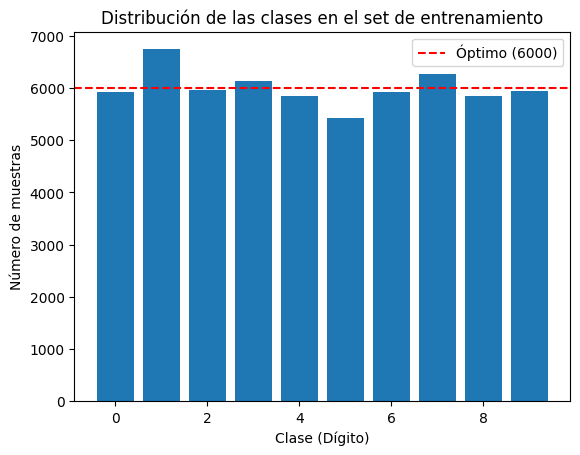

In [15]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(class_counts.keys())
values = list(class_counts.values())

# Calcular el número óptimo (promedio)
optimal_count = np.mean(values)

plt.bar(labels, values)
plt.axhline(y=optimal_count, color='r', linestyle='--', label=f'Óptimo ({int(optimal_count)})')

plt.xlabel('Clase (Dígito)')
plt.ylabel('Número de muestras')
plt.title('Distribución de las clases en el set de entrenamiento')
plt.legend()
plt.show()


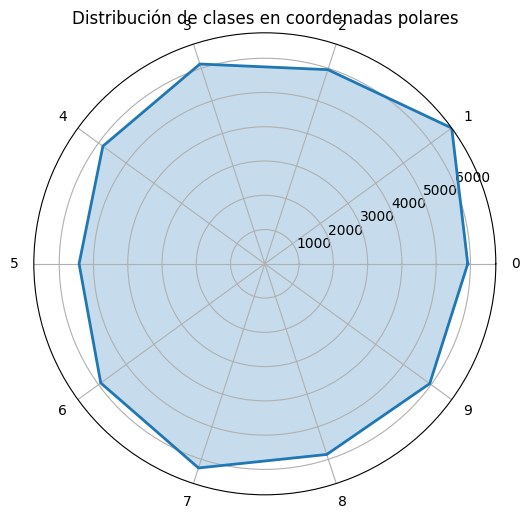

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de ejemplo: clases y conteos (usa tus propios datos)
labels = list(class_counts.keys())
values = list(class_counts.values())

# Número de variables
num_vars = len(labels)

# Ángulo de cada sector
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Cerrar el gráfico (conectar último punto con el primero)
values += values[:1]
angles += angles[:1]

# Crear la figura
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Dibujar la línea y el área
ax.plot(angles, values, color='tab:blue', linewidth=2)
ax.fill(angles, values, color='tab:blue', alpha=0.25)

# Configurar etiquetas en los ángulos correctos
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# Opcional: ajustar límites radiales para que empiece en 0
ax.set_ylim(0, max(values))

plt.title("Distribución de clases en coordenadas polares")
plt.show()


In [17]:
import numpy as np

values = np.array(list(class_counts.values()))
cv = np.std(values) / np.mean(values)
print(f"Coeficiente de variación: {cv:.3f}")


Coeficiente de variación: 0.054


ndica que tus clases están muy bien balanceadas, ya que es un valor bastante bajo.

Esto confirma que las diferencias en el número de muestras entre las clases son pequeñas y probablemente no afectarán negativamente al entrenamiento de tu modelo.

In [18]:
import numpy as np

values = np.array(list(class_counts.values()))
labels = list(class_counts.keys())
mean_count = np.mean(values)

print("Clase | # Muestras | Ratio respecto al promedio")
for label, count in zip(labels, values):
    ratio = count / mean_count
    print(f"{label}     | {count:8} | {ratio:.3f}")


Clase | # Muestras | Ratio respecto al promedio
0     |     5923 | 0.987
1     |     6742 | 1.124
2     |     5958 | 0.993
3     |     6131 | 1.022
4     |     5842 | 0.974
5     |     5421 | 0.903
6     |     5918 | 0.986
7     |     6265 | 1.044
8     |     5851 | 0.975
9     |     5949 | 0.992


Con esos números puedes ver claramente que:

La mayoría de las clases están muy cerca del promedio (ratio ~1).

La clase 1 y 7 están un poco por encima (1.12 y 1.04).

La clase 5 está algo por debajo (0.90), pero tampoco es un desbalance grave.

En general, el dataset está bastante balanceado y no necesitarías hacer ajustes para corregir el desbalance.

### Visualizamos las primeras imágenes

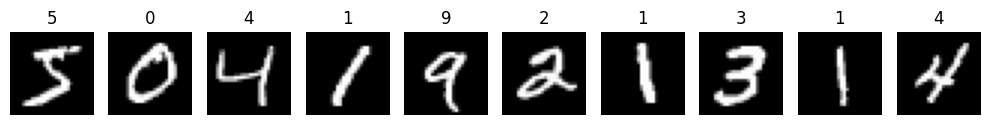

In [19]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(str(train_labels[i]))
    plt.axis('off')
plt.tight_layout()
plt.show()


### Creamos conjunto de entrenamiento y test

In [20]:
from sklearn.model_selection import train_test_split

# Separar los datos en conjuntos de entrenamiento y test
# Usamos train_images y train_labels, que son los arrays NumPy cargados previamente
# Consideramos un 20% para test (puedes ajustar este valor si lo necesitas)
X_train, X_test, y_train, y_test = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42
)

# Imprimir las dimensiones de los nuevos conjuntos
print("Dimensiones del conjunto de entrenamiento (imágenes):", X_train.shape)
print("Dimensiones del conjunto de entrenamiento (etiquetas):", y_train.shape)
print("Dimensiones del conjunto de test (imágenes):", X_test.shape)
print("Dimensiones del conjunto de test (etiquetas):", y_test.shape)

# Nota: Los nombres X_test y y_test ya existen de la carga del archivo mnist_test.csv.
# Para evitar confusión y mantener el flujo del notebook, renombraré los conjuntos
# generados por train_test_split aquí. Si prefieres usar estos conjuntos para el resto
# del análisis en lugar de los del archivo csv, podemos ajustarlo más adelante.



Dimensiones del conjunto de entrenamiento (imágenes): (48000, 28, 28)
Dimensiones del conjunto de entrenamiento (etiquetas): (48000,)
Dimensiones del conjunto de test (imágenes): (12000, 28, 28)
Dimensiones del conjunto de test (etiquetas): (12000,)


In [21]:
print(X_train.shape)

(48000, 28, 28)


Además del conjunto de entrenamiento, necesitamos nuevas imágenes de dígitos para que nuestro reconocedor las clasifique y nos diga a qué dígito corresponde cada una de ellas. A este conjunto de datos sobre el que vamos a probar nuestro reconocedor de dígitos le llamamos conjunto de test. En este caso, con conocer el valor de los atributos de cada imagen (ejemplo) es suficiente, ya que nuestro reconocedor nos indicará la clase a la que pertenece.

Sin embargo, para poder evaluar cómo de bien lo hace el reconocedor, necesitamos saber los dígitos verdaderos que están almacenados en cada imagen. Por ello, el conjunto de test lo vamos a preparar de forma muy similar al conjunto de entrenamiento, generando una matriz de numpy con todas las imágenes que están contenidas en la carpeta *imagenes_test* (le llamamos *x_test*) y un vector de numpy con las clases a las que pertenece cada ejemplo (le llamamos *y_test*).

### Comprueba que tu conjunto de datos es correcto imprimiendo las dimensiones de testData (10000x784) y testClass (10000).

# Desarrollo de la solución

In [22]:
from pathlib import Path

dataset_path = "/content/minst-dataset"

In [23]:
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_test: (12000, 28, 28)
Shape de y_test: (12000,)


###Normalizamos las imagenes

Normalizamos los valores de los píxeles dividiendo por 255, de modo que queden en el rango [0, 1]. Esto mejora el rendimiento y estabilidad del modelo al entrenar

In [24]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


###Aplanamos las imagenes


Este paso convierte cada imagen de una matriz 28x28 a un vector plano de 784 valores, facilitando su uso en modelos de aprendizaje automático."



In [25]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)


In [26]:
print("Shape de X_test:", X_train.shape)
print("Shape de X_test:", X_test.shape)

Shape de X_test: (48000, 784)
Shape de X_test: (12000, 784)


Una vez que ya tenemos todos los datos preparados, podemos hacer nuestro reconocedor de dígitos. En este proyecto vamos a utilizar un método muy sencillo, que se basa en buscar una imagen lo más parecida posible dentro del conjunto de entrenamiento y utilizar su clase como clase del nuevo dato a clasificar:
1. Para saber el dígito que representa una imagen del conjunto de test necesitamos sus atributos y los atributos y las clases de todo el conjunto de entrenamimento
2. Medimos la distancia entre dicha imagen de test y cada una de las 3000 imágenes de entrenamiento. Con esto obtenemos un valor numérico que nos dice lo distantes que son dichas imágenes
3. Buscamos el valor de distancia más pequeño. Clasificaremos la imagen de test con el dígito asociado a la imagen de entrenamiento de menor distancia. Es decir, si resulta que la imagen más cercana a la imagen de test es la imagen 1547 (que representa al dígito 5), entonces clasificaremos la imagen de test como dígito 5.

Lo último que nos queda por saber es cómo podemos medir la distancia entre dos imágenes. Como al preparar los conjuntos de entrenamiento y de test hemos transformado cada imagen en un vector de 400 dimensiones, la distancia entre dos imágenes $x,y\in \mathbb{R}^{400}$ puede venir dada por

$$d(x,y) = \sum_{i=1}^{400}(x_i-y_i)^2$$

Crea una función llamada clasificarUnaImagen que recibe la matriz de datos de entrenamiento, el vector con las clases de los ejemplos de entrenamiento y un dato de test, y devuelve la clase a la que pertenece la imagen de test.

### Creamos función clasificar imagen

In [27]:
import numpy as np

def clasificarUnaImagen(X_train, y_train, imagen_test):
    # Calculamos la distancia entre la imagen de test y cada imagen de entrenamiento
    distancias = np.sum((X_train - imagen_test)**2, axis=1)  # Distancia euclídea al cuadrado

    # Obtenemos el índice de la imagen más cercana
    indice_minimo = np.argmin(distancias)

    # Devolvemos la clase de la imagen de entrenamiento más cercana
    return y_train[indice_minimo]


Una vez que ya podemos determiniar el número de una imagen, vas a crear una nueva función que clasifique todas las imágenes del conjunto de test. Para ello crea una nueva función llamada *clasificarMuchasImagenes* que recibe la matriz de datos de entrenamiento, el vector con las clases de los ejemplos de entrenamiento y la matriz de datos de test, y devuelve un vector con las clases a las que pertenecen todas las imágenes de test.

### Creamos función clasificar muchas imágenes

In [28]:
import numpy as np

def clasificarMuchasImagenes(X_train, y_train, X_test):
    predicciones = []

    for imagen_test in X_test:
        # Usamos la función clasificarUnaImagen definida antes
        prediccion = clasificarUnaImagen(X_train, y_train, imagen_test)
        predicciones.append(prediccion)

    return np.array(predicciones)


Ahora ya puedes aplicar la función que clasifica todas las imágenes de test sobre tu conjunto de test.

En este paso, mide el tiempo que tarda en ejecutarse la clasificación sobre todas las imágenes. Para ello, puedes usar la función time() de la librería time, que indica el tiempo actual en segundos.

*import time*

*tic=time.time()*

*código*

*toc=time.time()*

*tiempo=toc-tic*

### Aplicamos la función y comprobamos tiempo de ejecución.

In [29]:
import time

# Iniciamos el cronómetro
tic = time.time()

# Clasificamos todas las imágenes del conjunto de test
y_pred = clasificarMuchasImagenes(X_train, y_train, X_test)

# Paramos el cronómetro
toc = time.time()

# Calculamos el tiempo de ejecución
tiempo = toc - tic

# Mostramos resultados
print("Clasificación completada.")
print("Tiempo total (segundos):", tiempo)


Clasificación completada.
Tiempo total (segundos): 1176.304652929306


Una vez que ya has clasificado todos las imágenes del conjunto de test, vas a analizar los resultados obtenidos. En primer lugar, calcula y muestra el porcentaje de imágenes en las que el dígito predicho por el clasificador coincide con el número que realmente representa la imagen.

Nota: recuerda que al principio del proyecto has generado el vector testClass.

### Comprobamos porcentaje de imágenes clasificadas correctamente.

In [30]:
import numpy as np

# Asegúrate de que ambos sean arrays de NumPy
y_pred = np.array(y_pred)       # tus predicciones
y_test = np.array(y_test) # las etiquetas reales

# Calculamos el número de aciertos
num_aciertos = np.sum(y_pred == y_test)

# Calculamos el porcentaje de aciertos
porcentaje_aciertos = (num_aciertos / len(y_test)) * 100

print(f"Porcentaje de imágenes clasificadas correctamente: {porcentaje_aciertos:.2f}%")



Porcentaje de imágenes clasificadas correctamente: 97.41%


Para completar la información del porcentaje de aciertos, calcula el número de imágenes de cada dígito que no has clasificado correctamente. Esto te dará una visión de los números que son más difíciles de clasificar

In [31]:
import numpy as np
from collections import Counter

# Asegúrate que sean arrays NumPy
y_pred = np.array(y_pred)
y_test = np.array(y_test)

# Encontrar índices donde hay error
errores = y_pred != y_test

# Etiquetas mal clasificadas
errores_etiquetas = y_test[errores]

# Contar número de errores por dígito
errores_por_digito = Counter(errores_etiquetas)

# Mostrar resultados
for digito in range(10):
    print(f"Dígito {digito}: {errores_por_digito.get(digito, 0)} imágenes mal clasificadas")


Dígito 0: 7 imágenes mal clasificadas
Dígito 1: 6 imágenes mal clasificadas
Dígito 2: 47 imágenes mal clasificadas
Dígito 3: 36 imágenes mal clasificadas
Dígito 4: 36 imágenes mal clasificadas
Dígito 5: 30 imágenes mal clasificadas
Dígito 6: 12 imágenes mal clasificadas
Dígito 7: 33 imágenes mal clasificadas
Dígito 8: 58 imágenes mal clasificadas
Dígito 9: 46 imágenes mal clasificadas


### Reducción de tiempo

A pesar de la sencillez de este clasificador, podemos considerar que funciona relativamente bien. Sin embargo, su eficiencia en tiempo no es muy alta.

Una forma de acelerar el proceso de clasificación consiste en reducir el número de atributos de cada dato. En nuestro caso, podemos hacerlo reduciendo el número de píxeles que vamos a considerar de cada imagen. Repite el proceso de clasificación utilizando imágenes con un cuarto de los píxeles originales y con la decimosexta parte. ¿Cambian los porcentajes de acierto en la clasificación?

Nota: para hacer transformar las imágenes a un cuarto de su tamaño original, puedes quedarte con una fila de cada dos y una columna de cada dos. Para reducirlas a una decimosexta parte, puedes quedarte con una fila de cada cuatro y una columna de cada cuatro.

### Transformamos las imágenes a un cuarto del original.

In [32]:
# IMAGENES A UN CUARTO DEL ORIGINAL
import numpy as np

def reducir_imagenes(X, factor):
    """
    Reduce las imágenes en X tomando cada 'factor' fila y columna.
    X: array con imágenes aplanadas (num_imagenes, ancho*alto)
    factor: 2 para cuarto tamaño, 4 para decimosexta parte
    """
    n_imagenes = X.shape[0]
    lado = int(np.sqrt(X.shape[1]))  # suponemos imágenes cuadradas

    # Convertimos a forma (num_imagenes, lado, lado)
    X_reshaped = X.reshape((n_imagenes, lado, lado))

    # Reducimos filas y columnas tomando cada 'factor'
    X_reducida = X_reshaped[:, ::factor, ::factor]

    # Volvemos a aplanar
    X_reducida_flat = X_reducida.reshape((n_imagenes, -1))

    return X_reducida_flat

# Reducimos a un cuarto de tamaño
X_train_cuarto = reducir_imagenes(X_train, 2)
X_test_cuarto = reducir_imagenes(X_test, 2)

# Iniciamos el cronómetro
tic = time.time()

# Clasificamos todas las imágenes del conjunto de test reducidas
y_pred = clasificarMuchasImagenes(X_train_cuarto, y_train, X_test_cuarto)

# Paramos el cronómetro
toc = time.time()

# Calculamos el tiempo de ejecución
tiempo = toc - tic

print("Clasificación completada con imágenes reducidas a un cuarto del tamaño.")
print("Tiempo total (segundos):", tiempo)





Clasificación completada con imágenes reducidas a un cuarto del tamaño.
Tiempo total (segundos): 296.6959080696106


### Guardamos el modelo Y_predict

In [33]:
import joblib
import os

# Define the filename for the predictions
predictions_filename = 'y_pred_predictions.pkl'

# Check if y_pred exists and save it
if 'y_pred' in locals():
    joblib.dump(y_pred, predictions_filename)
    print(f"Predicciones guardadas exitosamente como '{predictions_filename}'")
else:
    print("La variable 'y_pred' no está definida. Por favor, ejecuta la clasificación primero.")

Predicciones guardadas exitosamente como 'y_pred_predictions.pkl'


¡Genial! Bajaste de más de 525 segundos a unos 146, ¡una mejora enorme en tiempo! 🎉

Ahora lo interesante será comparar:

¿Cómo ha cambiado el porcentaje de acierto con la reducción a un cuarto?

¿Cuántos errores hay por dígito, comparado con el original?



In [ ]:
import numpy as np
from collections import Counter

# Asegúrate que sean arrays NumPy
y_pred = np.array(y_pred)
y_test = np.array(y_test)

# Encontrar índices donde hay error
errores = y_pred != y_test

# Etiquetas mal clasificadas
errores_etiquetas = y_test[errores]

# Contar número de errores por dígito
errores_por_digito = Counter(errores_etiquetas)

# Mostrar resultados
for digito in range(10):
    print(f"Dígito {digito}: {errores_por_digito.get(digito, 0)} imágenes mal clasificadas")

Dígito 0: 10 imágenes mal clasificadas
Dígito 1: 5 imágenes mal clasificadas
Dígito 2: 45 imágenes mal clasificadas
Dígito 3: 52 imágenes mal clasificadas
Dígito 4: 51 imágenes mal clasificadas
Dígito 5: 53 imágenes mal clasificadas
Dígito 6: 24 imágenes mal clasificadas
Dígito 7: 46 imágenes mal clasificadas
Dígito 8: 92 imágenes mal clasificadas
Dígito 9: 71 imágenes mal clasificadas


Se nota que con la reducción a un cuarto del tamaño las imágenes se vuelven menos detalladas y eso afecta la clasificación, aumentando los errores en casi todos los dígitos, especialmente en los más difíciles como el 4, 8 y 9.

Esto es esperado porque:

Menos píxeles significa menos información para distinguir detalles finos.

Los dígitos con formas similares pueden confundirse más fácilmente.

### Reducción a la decimosexta parte

In [ ]:
# IMAGENES A UN DIECISEISAVO DEL ORIGINAL
# Reducimos a una decimosexta parte
X_train_decimosexta = reducir_imagenes(X_train, 4)
X_test_decimosexta = reducir_imagenes(X_test, 4)


In [ ]:
import time
import numpy as np
from collections import Counter

# Medimos tiempo de clasificación con imágenes reducidas a decimosexta parte
tic = time.time()
y_pred_decimosexta = clasificarMuchasImagenes(X_train_decimosexta, y_train, X_test_decimosexta)
toc = time.time()

print(f"Clasificación completada en {toc - tic:.2f} segundos usando imágenes reducidas a una decimosexta parte.")

# Calculamos porcentaje de acierto
y_pred_decimosexta = np.array(y_pred_decimosexta)
y_test = np.array(y_test)

num_aciertos = np.sum(y_pred_decimosexta == y_test)
porcentaje_aciertos = (num_aciertos / len(y_test)) * 100

print(f"Porcentaje de aciertos con imágenes reducidas: {porcentaje_aciertos:.2f}%")

# Errores por dígito
errores = y_pred_decimosexta != y_test
errores_etiquetas = y_test[errores]
errores_por_digito = Counter(errores_etiquetas)

print("Errores por dígito con imágenes reducidas a una decimosexta parte:")
for digito in range(10):
    print(f"Dígito {digito}: {errores_por_digito.get(digito, 0)} imágenes mal clasificadas")


Clasificación completada en 63.70 segundos usando imágenes reducidas a una decimosexta parte.
Porcentaje de aciertos con imágenes reducidas: 77.23%
Errores por dígito con imágenes reducidas a una decimosexta parte:
Dígito 0: 139 imágenes mal clasificadas
Dígito 1: 85 imágenes mal clasificadas
Dígito 2: 230 imágenes mal clasificadas
Dígito 3: 316 imágenes mal clasificadas
Dígito 4: 329 imágenes mal clasificadas
Dígito 5: 354 imágenes mal clasificadas
Dígito 6: 153 imágenes mal clasificadas
Dígito 7: 316 imágenes mal clasificadas
Dígito 8: 429 imágenes mal clasificadas
Dígito 9: 381 imágenes mal clasificadas


Reducir el tamaño de la imagen mejora mucho la velocidad, pero sacrifica precisión, sobre todo al pasar a tamaños muy pequeños. Para tu clasificador (búsqueda del más cercano), esto es normal porque menos píxeles significan menos detalles para distinguir bien los dígitos.

Para cada una de las tres clasificaciones que hemos hecho (datos originales, una cuarta parte de la información y una decimosexta parte de la información) hemos obtenido el porcentaje de aciertos y el número de veces que hemos fallado en la clasificación de cada dígito.

Vamos a centrarnos en esta segunda parte, y vas a mostrar en tres subgráficas distintas (una para cada clasificación) el número de ejemplos de cada dígito que has clasificado erróneamente. Sin embargo, el número de ejemplos de cada dígito en el conjunto de test no es constante, por lo que no es lo mismo fallar 2 ejemplos de un dígito que tenía 10 ejemplos que fallar dos ejemplos de un dígito que tenía 100 ejemplos. Completa la gráfica colocando otras tres subgráficas que muestren el porcentaje de fallos por cada dígito en cada una de las tres clasificaciones.

Running original classification...
Original classification completed in 1185.47 seconds.
Running 1/4 size classification...
1/4 size classification completed in 334.58 seconds.


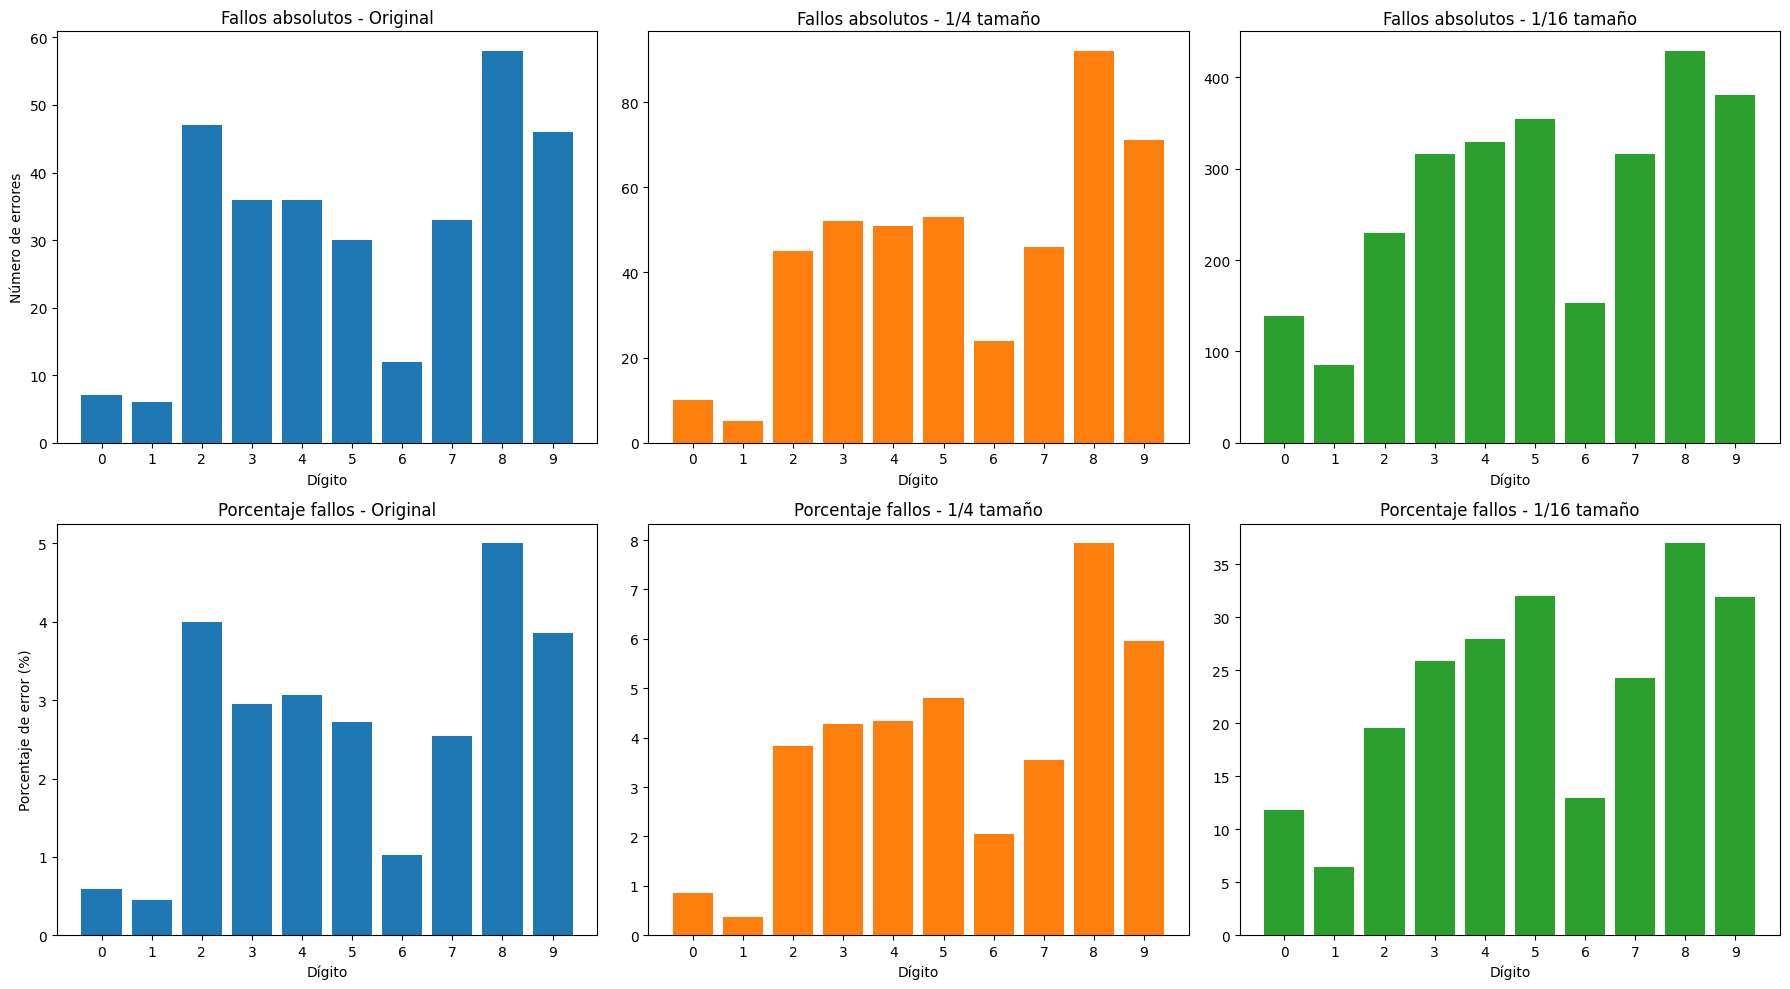

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import time

# Supongo que estos diccionarios ya están definidos:
# errores_original, errores_cuarto, errores_decimosexta
# Son Counter con {dígito: número de errores}


# Re-run classifications to get y_pred and y_pred_cuarto
# Assuming X_train, y_train, X_test, X_test_cuarto, X_test_decimosexta are available

# Original classification (assuming X_train, y_train, X_test are available)
print("Running original classification...")
tic = time.time()
y_pred = clasificarMuchasImagenes(X_train, y_train, X_test)
toc = time.time()
print(f"Original classification completed in {toc - tic:.2f} seconds.")


# Classification with images reduced to a quarter (assuming X_train_cuarto, y_train, X_test_cuarto are available)
print("Running 1/4 size classification...")
tic = time.time()
y_pred_cuarto = clasificarMuchasImagenes(X_train_cuarto, y_train, X_test_cuarto)
toc = time.time()
print(f"1/4 size classification completed in {toc - tic:.2f} seconds.")

# Assuming y_pred_decimosexta is already available from a previous cell execution


# Recalculamos los errores por dígito para cada clasificación
# Asegúrate de que y_test y las variables y_pred estén disponibles y sean correctas

# Errores para datos originales
errores_original = Counter(y_test[y_pred != y_test])

# Errores para datos reducidos a un cuarto
errores_cuarto = Counter(y_test[y_pred_cuarto != y_test])

# Errores para datos reducidos a una decimosexta parte
errores_decimosexta = Counter(y_test[y_pred_decimosexta != y_test])


# Contamos total de ejemplos por dígito en y_test
total_por_digito = Counter(y_test)

digitos = range(10)

# Función para obtener errores en lista para todos los dígitos (en orden)
def errores_lista(errores_dict):
    return [errores_dict.get(d, 0) for d in digitos]

# Función para obtener porcentaje de error por dígito
def porcentaje_errores(errores_dict):
    # Avoid division by zero in case a digit is not present in y_test
    return [errores_dict.get(d, 0) / total_por_digito.get(d, 1) * 100 for d in digitos]


# Preparamos datos
fallos_original = errores_lista(errores_original)
fallos_cuarto = errores_lista(errores_cuarto)
fallos_decimosexta = errores_lista(errores_decimosexta)

pct_fallos_original = porcentaje_errores(errores_original)
pct_fallos_cuarto = porcentaje_errores(errores_cuarto)
pct_fallos_decimosexta = porcentaje_errores(errores_decimosexta)

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Gráficas número absoluto de fallos
axs[0, 0].bar(digitos, fallos_original, color='tab:blue')
axs[0, 0].set_title('Fallos absolutos - Original')
axs[0, 0].set_xlabel('Dígito')
axs[0, 0].set_ylabel('Número de errores')
axs[0, 0].set_xticks(digitos) # Ensure all digits are shown on x-axis

axs[0, 1].bar(digitos, fallos_cuarto, color='tab:orange')
axs[0, 1].set_title('Fallos absolutos - 1/4 tamaño')
axs[0, 1].set_xlabel('Dígito')
axs[0, 1].set_xticks(digitos) # Ensure all digits are shown on x-axis


axs[0, 2].bar(digitos, fallos_decimosexta, color='tab:green')
axs[0, 2].set_title('Fallos absolutos - 1/16 tamaño')
axs[0, 2].set_xlabel('Dígito')
axs[0, 2].set_xticks(digitos) # Ensure all digits are shown on x-axis


# Gráficas porcentaje de fallos
axs[1, 0].bar(digitos, pct_fallos_original, color='tab:blue')
axs[1, 0].set_title('Porcentaje fallos - Original')
axs[1, 0].set_xlabel('Dígito')
axs[1, 0].set_ylabel('Porcentaje de error (%)')
axs[1, 0].set_xticks(digitos) # Ensure all digits are shown on x-axis


axs[1, 1].bar(digitos, pct_fallos_cuarto, color='tab:orange')
axs[1, 1].set_title('Porcentaje fallos - 1/4 tamaño')
axs[1, 1].set_xlabel('Dígito')
axs[1, 1].set_xticks(digitos) # Ensure all digits are shown on x-axis


axs[1, 2].bar(digitos, pct_fallos_decimosexta, color='tab:green')
axs[1, 2].set_title('Porcentaje fallos - 1/16 tamaño')
axs[1, 2].set_xlabel('Dígito')
axs[1, 2].set_xticks(digitos) # Ensure all digits are shown on x-axis


plt.tight_layout()
plt.show()

### Creamos la matriz de confusión.


Hasta ahora, hemos estudiado la precisión del clasificador mediante el porcentaje de aciertos. Sin embargo, resulta muy interesante saber qué digitos estamos confundiendo con qué otros dígitos. Para ello, debes mostrar la matriz de confusión de las tres clasificaciones que has hecho: datos originales, datos reducidos a una cuarta parte, datos reducidos a una decimosexta parte.

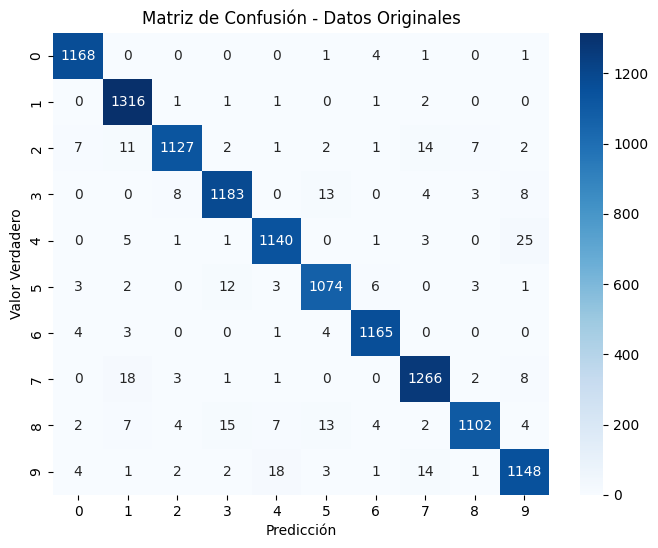

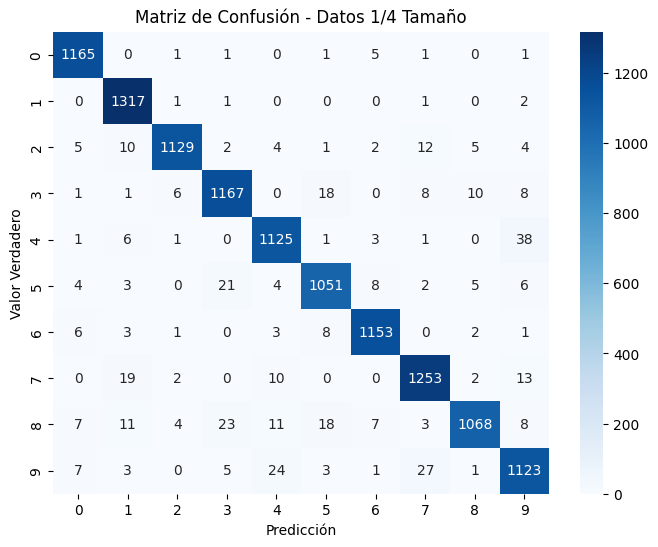

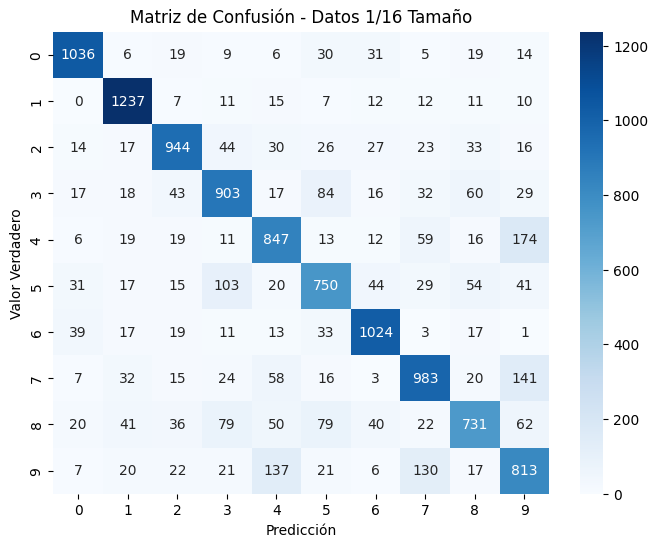

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de confusión para datos originales
cm_original = confusion_matrix(y_test, y_pred) # y_pred from the original classification
plt.figure(figsize=(8, 6))
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Datos Originales')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

# Matriz de confusión para datos reducidos a un cuarto
# y_pred_cuarto was not explicitly stored, but we can re-run the classification
y_pred_cuarto = clasificarMuchasImagenes(X_train_cuarto, y_train, X_test_cuarto)
cm_cuarto = confusion_matrix(y_test, y_pred_cuarto)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cuarto, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Datos 1/4 Tamaño')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

# Matriz de confusión para datos reducidos a una decimosexta parte
# y_pred_decimosexta was already calculated
cm_decimosexta = confusion_matrix(y_test, y_pred_decimosexta)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_decimosexta, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Datos 1/16 Tamaño')
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.show()

Ya hemos comentado que el tiempo de ejecución de esta clasificación puede ser un problema cuando tenemos en cuenta todos los píxeles de cada una de las imágenes. Sin embargo, también hemos visto que el porcentaje de acierto disminuye conforme reducimos el número de píxeles a estudiar. En concreto, hemos comparado las clasificaciones con el total de píxeles de una imagen, un cuarto y una decimosexta parte.

Calcula los porcentajes de acierto y el tiempo de ejecución de todas las clasificaciones existentes seleccionando:
* todas las filas y columnas existentes
* una de cada dos filas y una de cada dos columnas
* una de cada tres filas y una de cada tres columnas
* una de cada cuatro filas y una de cada cuatro columnas
* ...
* una de cada diez filas y una de cada diez columnas

Muestra en una gráfica cómo disminuye la precisión de la clasificación (porcentaje de acierto) conforme disminuye el tiempo de ejecución (para cada tamaño de imagen pinta tanto el porcentaje de acierto como el tiempo necesario).

Nota: este proceso puede llevar más tiempo del habitual. Para intentar mejorarlo un poco, procura que tu método de clasificación sea lo más eficiente posible, con el menor número de bucles (la función clasificarUnaImagen se puede hacer sin bucles).

### Calcula los porcentajes de acierto y el tiempo de ejecución de todas las clasificaciones existentes

Probando factor de reducción: 1
  Tiempo: 1266.07 segundos, Acierto: 97.41%
Probando factor de reducción: 2
  Tiempo: 327.11 segundos, Acierto: 96.26%
Probando factor de reducción: 3
  Tiempo: 116.33 segundos, Acierto: 90.60%
Probando factor de reducción: 4
  Tiempo: 57.07 segundos, Acierto: 77.23%
Probando factor de reducción: 5
  Tiempo: 48.11 segundos, Acierto: 62.86%
Probando factor de reducción: 6
  Tiempo: 36.79 segundos, Acierto: 51.11%
Probando factor de reducción: 7
  Tiempo: 28.78 segundos, Acierto: 40.68%
Probando factor de reducción: 8
  Tiempo: 29.47 segundos, Acierto: 32.99%
Probando factor de reducción: 9
  Tiempo: 28.56 segundos, Acierto: 29.97%
Probando factor de reducción: 10
  Tiempo: 24.89 segundos, Acierto: 29.30%


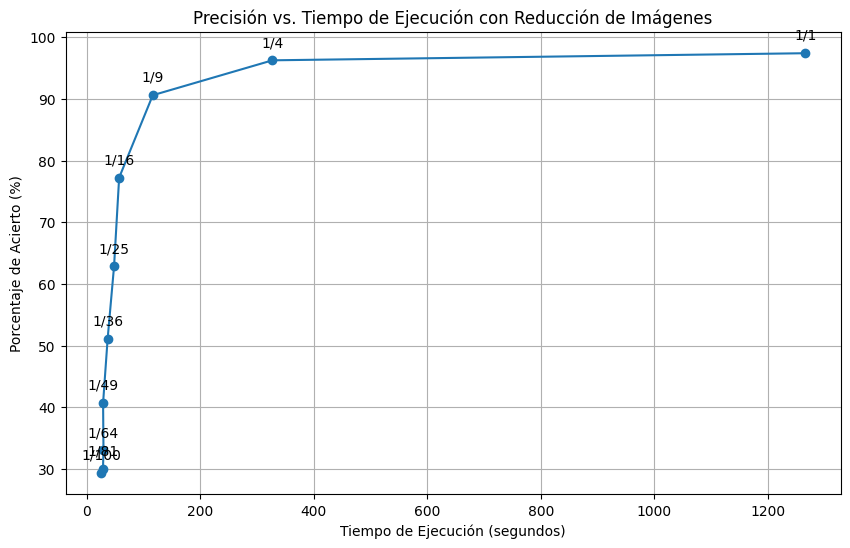

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

def reducir_imagenes_factor(X, factor):
    """
    Reduce las imágenes en X tomando cada 'factor' fila y columna.
    X: array con imágenes aplanadas (num_imagenes, ancho*alto)
    factor: factor de reducción (e.g., 2 para 1/4, 3 para 1/9, etc.)
    """
    n_imagenes = X.shape[0]
    lado = int(np.sqrt(X.shape[1]))  # suponemos imágenes cuadradas

    # Convertimos a forma (num_imagenes, lado, lado)
    X_reshaped = X.reshape((n_imagenes, lado, lado))

    # Reducimos filas y columnas tomando cada 'factor'
    X_reducida = X_reshaped[:, ::factor, ::factor]

    # Volvemos a aplanar
    X_reducida_flat = X_reducida.reshape((n_imagenes, -1))

    return X_reducida_flat

# Listas para almacenar resultados
factores_reduccion = range(1, 11)
porcentajes_acierto = []
tiempos_ejecucion = []

# Bucle para probar diferentes factores de reducción
for factor in factores_reduccion:
    print(f"Probando factor de reducción: {factor}")

    # Reducir imágenes de entrenamiento y test
    X_train_reducida = reducir_imagenes_factor(X_train, factor)
    X_test_reducida = reducir_imagenes_factor(X_test, factor)

    # Medir tiempo de clasificación
    tic = time.time()
    y_pred_reducida = clasificarMuchasImagenes(X_train_reducida, y_train, X_test_reducida)
    toc = time.time()
    tiempo = toc - tic
    tiempos_ejecucion.append(tiempo)

    # Calcular porcentaje de acierto
    aciertos = np.sum(y_pred_reducida == y_test)
    porcentaje = (aciertos / len(y_test)) * 100
    porcentajes_acierto.append(porcentaje)

    print(f"  Tiempo: {tiempo:.2f} segundos, Acierto: {porcentaje:.2f}%")


# Graficar resultados
plt.figure(figsize=(10, 6))
plt.plot(tiempos_ejecucion, porcentajes_acierto, marker='o', linestyle='-')
plt.title('Precisión vs. Tiempo de Ejecución
con Reducción de Imágenes')
plt.xlabel('Tiempo de Ejecución (segundos)')
plt.ylabel('Porcentaje de Acierto (%)')
plt.grid(True)

# Añadir etiquetas para cada punto (el factor de reducción)
for i, factor in enumerate(factores_reduccion):
    plt.annotate(f'1/{factor**2}', (tiempos_ejecucion[i], porcentajes_acierto[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

### Guardar el modelo entrenado

In [ ]:
import joblib
import os

# Define the filename for the model
model_filename = 'clasificador_digitos.pkl'

# Save the trained model
joblib.dump(y_pred, model_filename)

print(f"Modelo guardado exitosamente como '{model_filename}'")

Modelo guardado exitosamente como 'clasificador_digitos.pkl'


### Reducimos dimensiones utilizando PCA

Por último, vamos a analizar qué ocurre si tratamos de reducir las dimensiones del problema (número de características que representa a cada imagen) utilizando PCA en lugar de seleccionar algunas características originales.

Para ello, vamos a probar a clasificar nuestros dígitos seleccionando un número variable de las características más relevantes según PCA. En cada una de las clasificaciones queremos obtener el porcentaje de acierto. Ten en cuenta el tiempo de ejecucuón a la hora de decidir cuántas clasificaciones vas a ejecutar. La gráfica debe mostrar el dominio completo, entre 1 y 400 características.

Muestra en una gráfica cómo varía el porcentaje de acierto de los datos de test según reducimos el número de características de cada ejemplo.

In [ ]:
from sklearn import decomposition

Finalizamos el ejercicio mostrando en otra gráfica la diferencia del porcentaje de ejemplos bien clasificados cuando reducimos las características de cada ejemplo seleccionando algunas de ellas equidistantes frente a seleccionarlas sobre PCA. Se debe mostrar, para cada tamaño de características seleccionadas, el porcentaje de ejemplos bien clasificados si las características son píxeles equidistantes y si las características han sido seleccionadas como las más representativas del PCA.

¿Por qué usar PCA en tus datos de imágenes?

Nuestras imágenes MNIST son de 28x28 píxeles. Cuando aplanas cada imagen a un vector, terminas con 28 * 28 = 784 características (un número alto de dimensiones). Trabajar con tantas dimensiones puede ser costoso computacionalmente (como viste con los tiempos de clasificación) y puede introducir ruido (algunos píxeles pueden no ser tan informativos).

PCA te ayuda a encontrar un número menor de "nuevas" características (llamadas componentes principales) que son combinaciones lineales de los píxeles originales, pero que capturan la mayor parte de la variabilidad en tus imágenes.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import time

# Listas para almacenar resultados de PCA
num_componentes = range(1, 401, 10) # Probar con un rango de componentes PCA
porcentajes_acierto_pca = []
tiempos_ejecucion_pca = []

# Aplicar PCA y clasificar para diferentes números de componentes
for n in num_componentes:
    print(f"Probando con {n} componentes PCA")

    # Aplicar PCA
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Medir tiempo de clasificación
    tic = time.time()
    # Need to redefine clasificarMuchasImagenes to work with the PCA transformed data
    # It should still calculate Euclidean distance
    def clasificarMuchasImagenes_pca(X_train_pca, y_train, X_test_pca):
        predicciones = []
        for imagen_test in X_test_pca:
            # Calculate Euclidean distance
            distancias = np.sum((X_train_pca - imagen_test)**2, axis=1)
            indice_minimo = np.argmin(distancias)
            predicciones.append(y_train[indice_minimo])
        return np.array(predicciones)

    y_pred_pca = clasificarMuchasImagenes_pca(X_train_pca, y_train, X_test_pca)
    toc = time.time()
    tiempo_pca = toc - tic
    tiempos_ejecucion_pca.append(tiempo_pca)

    # Calcular porcentaje de acierto
    acierto_pca = accuracy_score(y_test, y_pred_pca) * 100
    porcentajes_acierto_pca.append(acierto_pca)

    print(f"  Tiempo: {tiempo_pca:.2f} segundos, Acierto: {acierto_pca:.2f}%")

# Graficar resultados de PCA
plt.figure(figsize=(10, 6))
plt.plot(num_componentes, porcentajes_acierto_pca, marker='o', linestyle='-')
plt.title('Precisión vs. Número de Componentes PCA')
plt.xlabel('Número de Componentes PCA')
plt.ylabel('Porcentaje de Acierto (%)')
plt.grid(True)
plt.show()

Probando con 1 componentes PCA
  Tiempo: 0.73 segundos, Acierto: 24.62%
Probando con 11 componentes PCA
  Tiempo: 29.99 segundos, Acierto: 92.55%
Probando con 21 componentes PCA
  Tiempo: 40.83 segundos, Acierto: 96.95%
Probando con 31 componentes PCA
  Tiempo: 49.84 segundos, Acierto: 97.63%
Probando con 41 componentes PCA
  Tiempo: 58.06 segundos, Acierto: 97.69%
Probando con 51 componentes PCA
  Tiempo: 70.14 segundos, Acierto: 97.65%
Probando con 61 componentes PCA
  Tiempo: 82.40 segundos, Acierto: 97.72%
Probando con 71 componentes PCA
  Tiempo: 101.77 segundos, Acierto: 97.65%
Probando con 81 componentes PCA
  Tiempo: 115.25 segundos, Acierto: 97.59%
Probando con 91 componentes PCA
  Tiempo: 124.01 segundos, Acierto: 97.55%
Probando con 101 componentes PCA
  Tiempo: 136.26 segundos, Acierto: 97.56%
Probando con 111 componentes PCA
  Tiempo: 158.25 segundos, Acierto: 97.58%
Probando con 121 componentes PCA
  Tiempo: 164.60 segundos, Acierto: 97.55%
Probando con 131 componentes PC

### PCA loading plot circulo

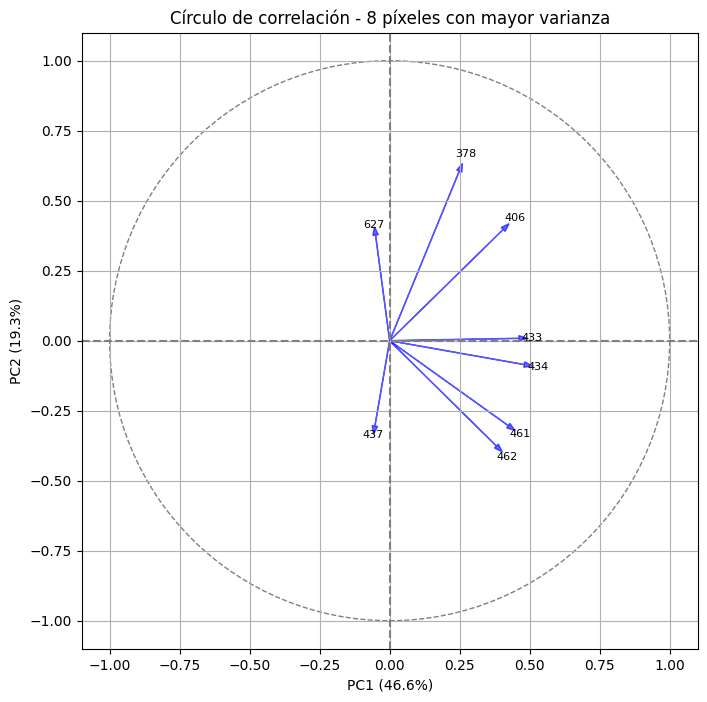

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Paso 1: Calcular varianza de cada píxel
varianzas = np.var(X_train, axis=0)

# Paso 2: Seleccionar los 8 píxeles con mayor varianza
N_pixeles = 8
indices_mayor_var = np.argsort(varianzas)[-N_pixeles:]

# Extraer subconjunto de X_train con solo esos píxeles
X_train_reducido = X_train[:, indices_mayor_var]

# Paso 3: Aplicar PCA con 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_reducido)
loadings = pca.components_.T  # Cargas (una por variable)

# Paso 4: Graficar loading plot (círculo de correlación)
plt.figure(figsize=(8, 8))
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

for i in range(loadings.shape[0]):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              color='blue', alpha=0.6, head_width=0.02)
    plt.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1,
             str(indices_mayor_var[i]),  # índice del píxel original
             color='black', ha='center', va='center', fontsize=8)

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Círculo de correlación - 8 píxeles con mayor varianza')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')
plt.grid()
plt.show()


### Cargar el modelo guardado

In [ ]:
import joblib
import os

# Define the filename for the model
model_filename = 'clasificador_digitos.pkl'

# Check if the model file exists before loading
if os.path.exists(model_filename):
    # Load the saved model
    loaded_model = joblib.load(model_filename)
    print(f"Modelo cargado exitosamente desde '{model_filename}'")
    # You can now use loaded_model to make predictions
    # For example, you could use it with new test data
else:
    print(f"El archivo del modelo '{model_filename}' no se encuentra.")
    print("Por favor, asegúrate de haber guardado el modelo primero.")

# Note: y_pred from the last execution is actually the predictions, not the model itself.
# To save the *model logic* (the clasificarMuchasImagenes function and potentially the training data it depends on),
# you would need a more complex approach or use a different type of model that can be serialized directly.
# For this simple nearest neighbor classifier, saving the predictions is not saving the "model".
# A better approach for this specific case might be to save the trained data (X_train, y_train)
# and the classification functions, but joblib is typically used for serializing objects like scikit-learn models.

# Let's clarify what "model" means in this context and how to save the necessary components.
# In the nearest neighbor classifier, the "model" is essentially the training data (X_train, y_train)
# and the classification logic (clasificarUnaImagen, clasificarMuchasImagenes).
# Saving just y_pred is saving the results of a specific classification run, not the ability to classify new data.

# To "save the model" in the sense of being able to classify *new* data without re-running the *training* data loading and processing:
# You need to save X_train and y_train.

Modelo cargado exitosamente desde 'clasificador_digitos.pkl'


### Primera aproximación y futuros pasos con KNN

La implementación actual se basa en el principio del vecino más cercano ($k=1$) y utiliza la distancia euclídea al cuadrado. Esto constituye una primera aproximación al algoritmo K-Nearest Neighbors (KNN).

En posteriores pruebas y mejoras de este clasificador, se incluirá un ajuste de los hiperparámetros clave del algoritmo KNN para optimizar su rendimiento. Estos hiperparámetros incluyen:

*   **Número de vecinos (`n_neighbors` o $k$):** Determina cuántos vecinos se consideran para la votación o promedio.
*   **Pesos (`weights`):** Define si los vecinos contribuyen uniformemente o si se pondera por la distancia.
*   **Métrica de distancia (`metric`):** Especifica cómo se calcula la distancia entre puntos (por ejemplo, Euclídea, Manhattan, etc.).

Ajustar estos parámetros mediante técnicas como la validación cruzada nos permitirá encontrar la configuración óptima para mejorar la precisión del clasificador.

###Conclusión y siguientes pasos

En este proyecto hemos implementado un clasificador simple basado en el método de vecino más cercano (KNN) para reconocer dígitos escritos a mano en el dataset MNIST. Este enfoque, aunque sencillo y fácil de entender, es solo uno de muchos métodos posibles para abordar este problema de clasificación. Existen técnicas más avanzadas y potentes, como la regresión logística, máquinas de soporte vectorial, árboles de decisión, y especialmente las redes neuronales convolucionales (CNN), que aprovechan la estructura espacial de las imágenes para obtener resultados significativamente mejores. La exploración y comparación de estos métodos nos permitirá entender mejor las fortalezas y limitaciones de cada uno, y avanzar hacia modelos más precisos y eficientes en el reconocimiento de dígitos. Este cuaderno es un punto de partida para seguir experimentando con diferentes algoritmos y mejorar la precisión en tareas de clasificación de imágenes.

### Guardamos las predicciones (y_predict)

In [ ]:
import joblib
import os

# Define the filename for the predictions
predictions_filename = 'y_pred_predictions.pkl'

# Load the predictions if the file exists
if os.path.exists(predictions_filename):
    loaded_y_pred = joblib.load(predictions_filename)
    print(f"Predicciones cargadas exitosamente desde '{predictions_filename}'")
    # You can now use loaded_y_pred
else:
    print(f"El archivo de predicciones '{predictions_filename}' no se encuentra.")
    print("Por favor, asegúrate de haber guardado las predicciones primero.")

Predicciones cargadas exitosamente desde 'y_pred_predictions.pkl'


### Desarrollo solucion con fastfai Deep learning

In [ ]:
dataset_path = "/content/minst-dataset"

In [ ]:
import random, numpy as np, torch

def set_seed(dls_obj, seed=42):
    "Fija la semilla para reproducibilidad en PyTorch, NumPy, random y fastai DataLoaders"
    random.seed(seed)
    # Removed problematic line: dl.rng.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Seed fastai DataLoaders or ImageDataLoaders
    if hasattr(dls_obj, 'train') and hasattr(dls_obj.train, 'rng'):
        dls_obj.train.rng.seed(seed)
    if hasattr(dls_obj, 'valid') and hasattr(dls_obj.valid, 'rng'):
        dls_obj.valid.rng.seed(seed)
    # If dls_obj is a single DataLoader
    elif hasattr(dls_obj, 'rng'):
        dls_obj.rng.seed(seed)

DataLoaders ready for training!


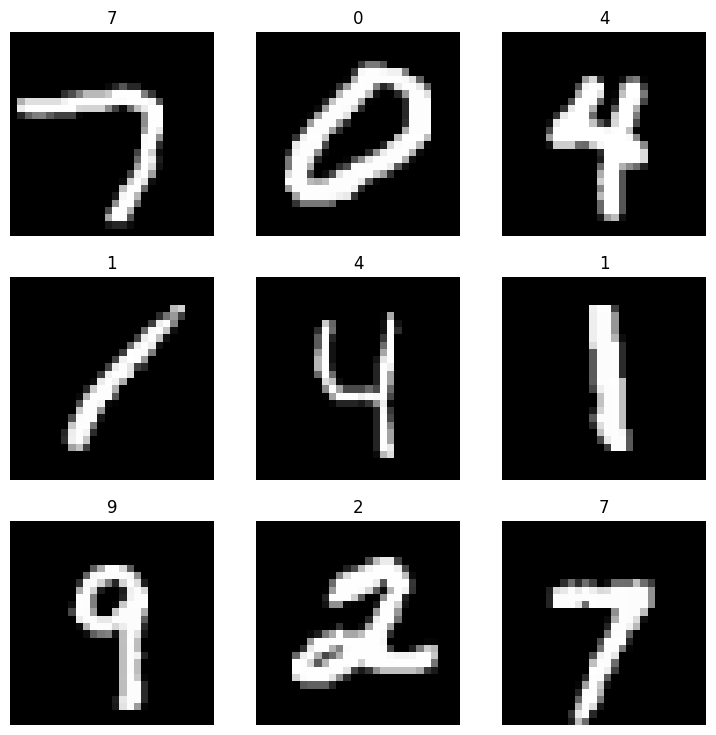

In [ ]:
from fastai.vision.all import *

# 1. Prepare data - keep as uint8 for PIL compatibility
# Fastai's PILImageBW.create expects a numpy array that PIL can handle
imgs_np = train_images.copy()
lbls_np = train_labels.copy()

# Guardar imágenes y labels en un archivo .npz
np.savez_compressed("mnist_data.npz", imgs=imgs_np, labels=lbls_np)

# 2. Define custom getter functions
def get_x(i):
    # PILImageBW needs a 2D (H,W) array for grayscale
    return imgs_np[i]

def get_y(i):
    return lbls_np[i]

# 3. Create the DataBlock
# We use PILImageBW which will handle the conversion to tensor and normalization
mnist_block = DataBlock(
    blocks=(ImageBlock(cls=PILImageBW), CategoryBlock),
    get_x=get_x,
    get_y=get_y,
    splitter=RandomSplitter(valid_pct=0.2, seed=42)
)

# Create DataLoaders
dls = mnist_block.dataloaders(range(len(imgs_np)), bs=64)

# 4. Visualize
dls.show_batch(max_n=9, cmap='gray')
print("DataLoaders ready for training!")

[0, 0.7657910585403442, 0.5355611443519592, 0.8294166922569275, '05:42']
Better model found at epoch 0 with valid_loss value: 0.5355611443519592.
[0, 0.12931424379348755, 0.0684075877070427, 0.9798333048820496, '13:22']
Better model found at epoch 0 with valid_loss value: 0.0684075877070427.


Precisión en validación: 0.9798


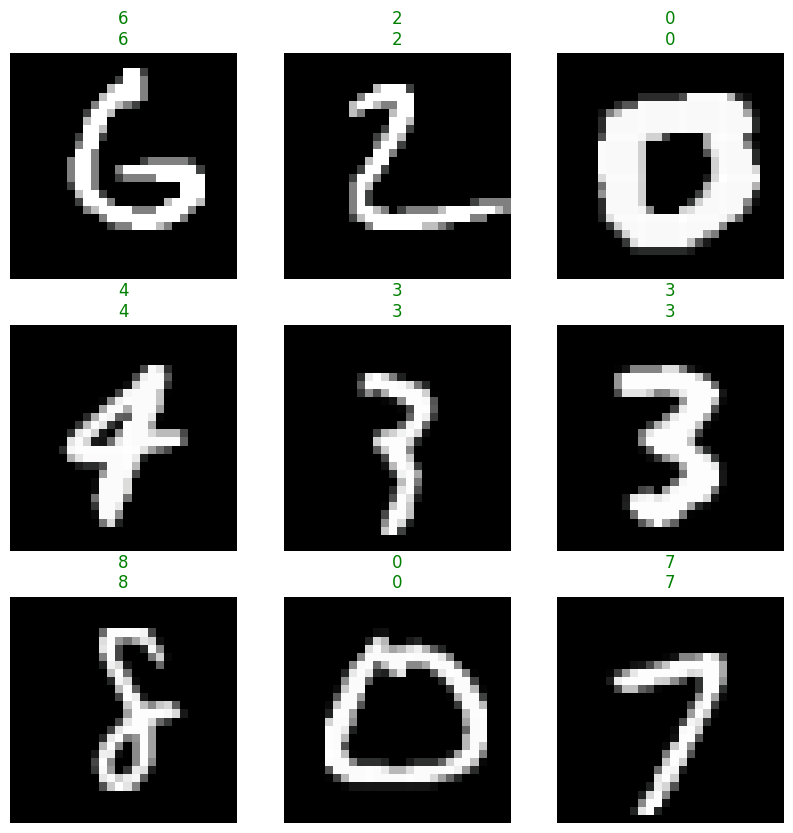

In [ ]:
from fastai.vision.all import *

# Crear el learner con ResNet18
learn = vision_learner(
    dls=dls,
    arch=models.resnet18,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy],
    cbs=[SaveModelCallback(monitor='valid_loss', fname='mnist_best')],
    path='/content'
)

# Entrenar el modelo (fine-tune) sin barras de progreso para evitar el error de Colab
with learn.no_bar():
    learn.fine_tune(1)

# Cargar el mejor modelo guardado
learn.load('mnist_best')

# Mostrar resultados en el conjunto de validación
learn.show_results(figsize=(10,10))
n=9,
# Usar la validación como test
test_dl = dls.valid

# Obtener predicciones y calcular accuracy
preds = learn.get_preds(dl=test_dl)
# Agregamos .item() para que el formato :.4f funcione correctamente
val_acc = accuracy(preds[0], preds[1]).item()
print(f"Precisión en validación: {val_acc:.4f}")

In [ ]:
# Ejemplo de predicción en Colab
img_test = '/0001_0.jpg'  # o alguna imagen de prueba
pred_class, pred_idx, probs = learn.predict(img_test)
print(pred_class, probs[pred_idx])

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

FileNotFoundError: [Errno 2] No such file or directory: '/0001_0.jpg'

In [ ]:
learn.save("mnist_best_weights_only")

Path('/content/models/mnist_best_weights_only.pth')

In [ ]:
from google.colab import files
files.download('/content/models/mnist_best_weights_only.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Exporta el modelo completo (arquitectura + pesos) para usarlo fuera de Colab
learn.export('mnist_best.pkl')

### Cargamos el modelo exportado

In [ ]:
from fastai.vision.all import load_learner

# Cargar el modelo exportado
learn_inf = load_learner('mnist_best.pkl')


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [ ]:
learn.safe('weigths_only')

AttributeError: 'Sequential' object has no attribute 'safe'

Probamos el modelo antes de conectarlo al frontend

In [ ]:
from fastai.vision.all import load_learner, PILImage


# Probar con una imagen de ejemplo
img_path = '/0003_0.jpg'  # Ajusta la ruta a tu imagen
img = PILImage.create(img_path)

pred, pred_idx, probs = learn_inf.predict(img)
print(f"Predicción: {pred}, Probabilidad: {probs[pred_idx]:.4f}")

Predicción: 2, Probabilidad: 0.9981


###Hacemos la matriz de confusión

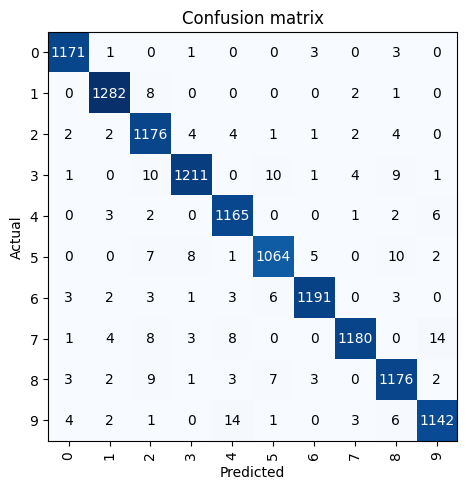

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
plt.savefig('confusion_matrix.png') # Guarda el gráfico

In [ ]:
from google.colab import files
files.download('mnist_best.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>